<a href="https://colab.research.google.com/github/kavyaayyappan1998/DATA266---2738/blob/main/Assignment6/Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 0 — Setup


In [2]:
# My SJSU ID is : 016052738
SID4 = 2738
SEED = 2738
SLICE = 738
HP_ID = 2
CLS_A = 8
CLS_B = 2

# Set random seeds explicitly for reproducibility.
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.transforms import functional as TF

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("SEED:", SEED)


Device: cuda
SEED: 2738


In [3]:
ROOT = "./data"
BATCH = 256
WORKERS = 2

mean = (0.4467, 0.4398, 0.4066)
std = (0.2603, 0.2566, 0.2713)

train_tf = transforms.Compose([
    transforms.RandomCrop(96, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_full = datasets.STL10(ROOT, split="train", download=True, transform=train_tf)
test_set = datasets.STL10(ROOT, split="test", download=True, transform=test_tf)
unlabeled_raw = datasets.STL10(ROOT, split="unlabeled", download=True)

g = torch.Generator().manual_seed(SEED)
idx500 = torch.randperm(len(train_full), generator=g)[:500].tolist()
train_500 = Subset(train_full, idx500)

train_loader = DataLoader(train_500, BATCH, shuffle=True, num_workers=WORKERS)
test_loader = DataLoader(test_set, BATCH, shuffle=False, num_workers=WORKERS)

classes = train_full.classes
print("Labeled subset:", len(train_500))
print("Unlabeled:", len(unlabeled_raw))
print("Test:", len(test_set))

100%|██████████| 2.64G/2.64G [05:00<00:00, 8.79MB/s]


Labeled subset: 500
Unlabeled: 100000
Test: 8000


Dataset Visualization


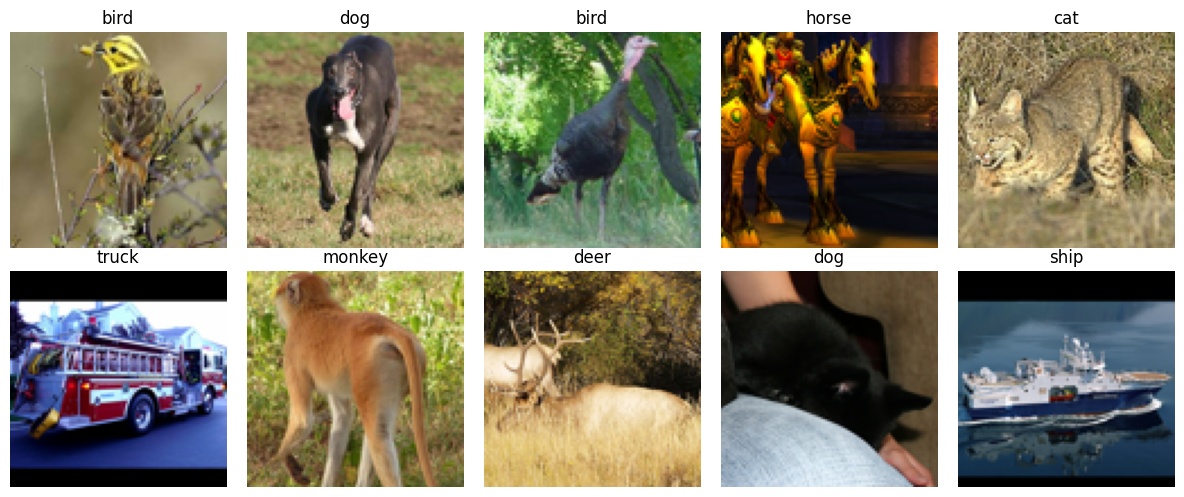

In [4]:
sample_ds = datasets.STL10(ROOT, split="train", download=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(axes.flat, range(10)):
    img, label = sample_ds[idx]
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()


In [5]:
def fit(model, loader, epochs, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"loss": [], "acc": []}

    for epoch in range(epochs):
        model.train()
        loss_sum = 0.0
        correct = 0
        total = 0

        for x, y in loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            opt.step()

            loss_sum += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

        epoch_loss = loss_sum / total
        epoch_acc = 100 * correct / total

        history["loss"].append(epoch_loss)
        history["acc"].append(epoch_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | loss {epoch_loss:.4f} | acc {epoch_acc:.2f}%")

    return history


Part A — Supervised with Limited Labels

In [6]:
def make_resnet18(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, num_classes)
    return model

def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

supervised = make_resnet18(10)
hist_supervised = fit(supervised, train_loader, epochs=12, lr=1e-3)

acc_supervised = accuracy(supervised, test_loader)
print(f"Part A test accuracy: {acc_supervised:.2f}%")

Epoch 01/12 | loss 2.3971 | acc 16.00%
Epoch 02/12 | loss 2.1002 | acc 22.20%
Epoch 03/12 | loss 1.8270 | acc 37.00%
Epoch 04/12 | loss 1.4775 | acc 47.20%
Epoch 05/12 | loss 1.2406 | acc 54.80%
Epoch 06/12 | loss 1.1009 | acc 61.40%
Epoch 07/12 | loss 0.8728 | acc 70.60%
Epoch 08/12 | loss 0.7408 | acc 76.60%
Epoch 09/12 | loss 0.6443 | acc 78.80%
Epoch 10/12 | loss 0.5280 | acc 82.60%
Epoch 11/12 | loss 0.3846 | acc 90.60%
Epoch 12/12 | loss 0.3032 | acc 90.40%
Part A test accuracy: 34.20%


Part A Training Curves


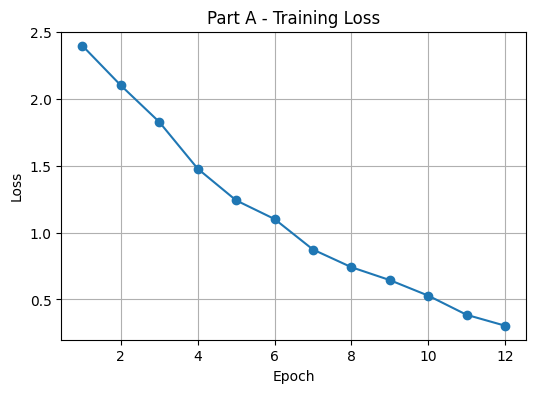

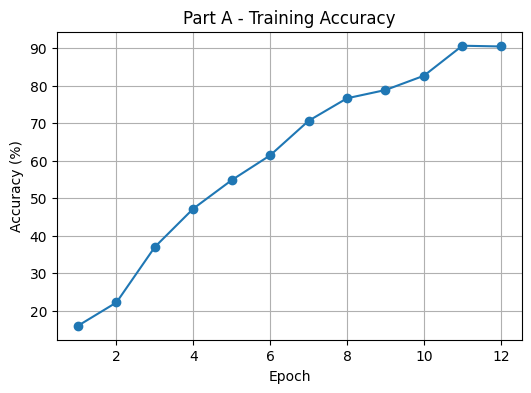

In [7]:
epochs = range(1, len(hist_supervised["loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, hist_supervised["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part A - Training Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, hist_supervised["acc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Part A - Training Accuracy")
plt.grid(True)
plt.show()


Part B — Rotation Self-Supervised Learning

In [8]:
class RotationDataset(Dataset):
    def __init__(self, base):
        self.base = base
        self.tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        img, _ = self.base[i]
        k = random.randrange(4)
        img = TF.rotate(img, 90 * k)
        return self.tf(img), k

rotation_loader = DataLoader(
    RotationDataset(unlabeled_raw),
    BATCH, shuffle=True, num_workers=WORKERS
)

rotation_model = make_resnet18(4)
hist_rotation_pretrain = fit(rotation_model, rotation_loader, epochs=15, lr=1e-3)

Epoch 01/15 | loss 0.9432 | acc 60.82%
Epoch 02/15 | loss 0.7422 | acc 70.52%
Epoch 03/15 | loss 0.6515 | acc 74.58%
Epoch 04/15 | loss 0.5843 | acc 77.37%
Epoch 05/15 | loss 0.5390 | acc 79.22%
Epoch 06/15 | loss 0.5010 | acc 80.85%
Epoch 07/15 | loss 0.4666 | acc 82.00%
Epoch 08/15 | loss 0.4416 | acc 83.31%
Epoch 09/15 | loss 0.4193 | acc 84.16%
Epoch 10/15 | loss 0.3949 | acc 84.94%
Epoch 11/15 | loss 0.3735 | acc 86.01%
Epoch 12/15 | loss 0.3570 | acc 86.68%
Epoch 13/15 | loss 0.3364 | acc 87.45%
Epoch 14/15 | loss 0.3212 | acc 88.03%
Epoch 15/15 | loss 0.3057 | acc 88.70%


In [9]:
rotation_encoder = rotation_model
rotation_encoder.fc = nn.Identity()

for p in rotation_encoder.parameters():
    p.requires_grad = False

class LinearProbe(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.fc = nn.Linear(512, 10)

    def forward(self, x):
        self.encoder.eval()
        with torch.no_grad():
            z = self.encoder(x)
        return self.fc(z)

rotation_probe = LinearProbe(rotation_encoder).to(device)
hist_rotation_probe = fit(rotation_probe, train_loader, epochs=18, lr=1e-3)

acc_rotation = accuracy(rotation_probe, test_loader)
print(f"Part B test accuracy: {acc_rotation:.2f}%")

Epoch 01/18 | loss 2.3490 | acc 9.00%
Epoch 02/18 | loss 2.2632 | acc 12.40%
Epoch 03/18 | loss 2.2301 | acc 19.20%
Epoch 04/18 | loss 2.1857 | acc 24.20%
Epoch 05/18 | loss 2.1424 | acc 27.80%
Epoch 06/18 | loss 2.1043 | acc 32.00%
Epoch 07/18 | loss 2.0696 | acc 35.20%
Epoch 08/18 | loss 2.0347 | acc 38.40%
Epoch 09/18 | loss 1.9981 | acc 36.60%
Epoch 10/18 | loss 1.9774 | acc 39.20%
Epoch 11/18 | loss 1.9361 | acc 40.20%
Epoch 12/18 | loss 1.9185 | acc 42.80%
Epoch 13/18 | loss 1.8987 | acc 41.60%
Epoch 14/18 | loss 1.8608 | acc 43.80%
Epoch 15/18 | loss 1.8483 | acc 42.80%
Epoch 16/18 | loss 1.8228 | acc 44.40%
Epoch 17/18 | loss 1.8136 | acc 43.60%
Epoch 18/18 | loss 1.7833 | acc 41.80%
Part B test accuracy: 38.30%


Part B Training Curves


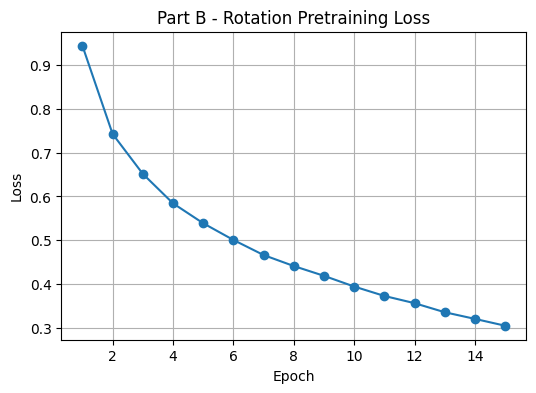

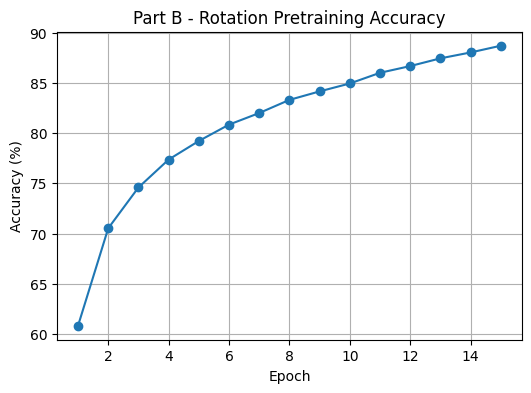

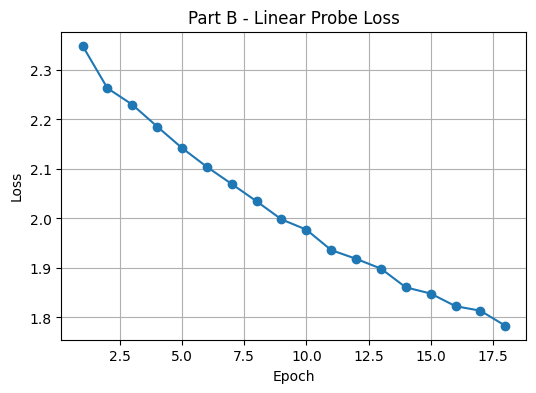

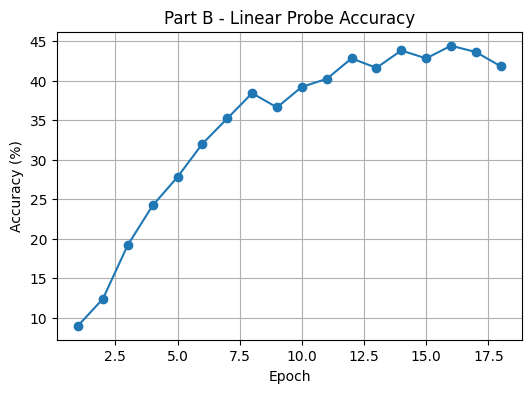

In [10]:
epochs_pre = range(1, len(hist_rotation_pretrain["loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_pre, hist_rotation_pretrain["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part B - Rotation Pretraining Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_pre, hist_rotation_pretrain["acc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Part B - Rotation Pretraining Accuracy")
plt.grid(True)
plt.show()

epochs_probe = range(1, len(hist_rotation_probe["loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_probe, hist_rotation_probe["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part B - Linear Probe Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_probe, hist_rotation_probe["acc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Part B - Linear Probe Accuracy")
plt.grid(True)
plt.show()


## Part C — SimCLR-Style Contrastive Learning

In [11]:
simclr_tf = transforms.Compose([
    transforms.RandomResizedCrop(96, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

class TwoViews(Dataset):
    def __init__(self, base, indices):
        self.base = base
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, _ = self.base[self.indices[i]]
        return simclr_tf(img), simclr_tf(img)

sim_idx = torch.randperm(len(unlabeled_raw), generator=g)[:20000].tolist()
sim_loader = DataLoader(
    TwoViews(unlabeled_raw, sim_idx),
    BATCH, shuffle=True, drop_last=True, num_workers=WORKERS
)

SimCLR Augmentation Preview



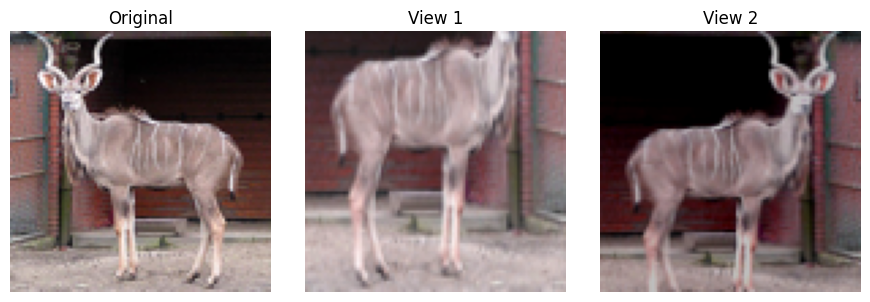

In [12]:
img, _ = unlabeled_raw[0]
view1 = simclr_tf(img)
view2 = simclr_tf(img)

def denormalize(x):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return (x.cpu() * std_t + mean_t).clamp(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(denormalize(view1).permute(1, 2, 0))
axes[1].set_title("View 1")
axes[1].axis("off")

axes[2].imshow(denormalize(view2).permute(1, 2, 0))
axes[2].set_title("View 2")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [13]:
class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = models.resnet18(weights=None)
        self.encoder.fc = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward(self, x):
        return self.projector(self.encoder(x))

def nt_xent(z1, z2, tau=0.2):
    z = F.normalize(torch.cat([z1, z2], dim=0), dim=1)
    sim = z @ z.T / tau
    n = z1.size(0)

    sim.fill_diagonal_(-1e9)
    targets = torch.cat([
        torch.arange(n, 2*n, device=z.device),
        torch.arange(0, n, device=z.device)
    ])
    return F.cross_entropy(sim, targets)

simclr = SimCLR().to(device)
opt = torch.optim.Adam(simclr.parameters(), lr=1e-3)

hist_simclr_pretrain = {"loss": []}

for epoch in range(18):
    simclr.train()
    loss_sum = 0.0

    for x1, x2 in sim_loader:
        x1, x2 = x1.to(device), x2.to(device)

        opt.zero_grad()
        loss = nt_xent(simclr(x1), simclr(x2), tau=0.2)
        loss.backward()
        opt.step()

        loss_sum += loss.item()

    epoch_loss = loss_sum / len(sim_loader)
    hist_simclr_pretrain["loss"].append(epoch_loss)

    print(f"Epoch {epoch+1:02d}/18 | loss {epoch_loss:.4f}")


Epoch 01/18 | loss 4.4479
Epoch 02/18 | loss 3.2473
Epoch 03/18 | loss 2.8635
Epoch 04/18 | loss 2.6926
Epoch 05/18 | loss 2.5724
Epoch 06/18 | loss 2.5120
Epoch 07/18 | loss 2.4532
Epoch 08/18 | loss 2.3910
Epoch 09/18 | loss 2.3491
Epoch 10/18 | loss 2.3262
Epoch 11/18 | loss 2.2950
Epoch 12/18 | loss 2.2764
Epoch 13/18 | loss 2.2517
Epoch 14/18 | loss 2.2289
Epoch 15/18 | loss 2.2045
Epoch 16/18 | loss 2.1895
Epoch 17/18 | loss 2.1792
Epoch 18/18 | loss 2.1677


In [14]:
simclr_encoder = simclr.encoder

for p in simclr_encoder.parameters():
    p.requires_grad = False

simclr_probe = LinearProbe(simclr_encoder).to(device)
hist_simclr_probe = fit(simclr_probe, train_loader, epochs=18, lr=1e-3)

acc_simclr = accuracy(simclr_probe, test_loader)
print(f"Part C test accuracy: {acc_simclr:.2f}%")

Epoch 01/18 | loss 2.4633 | acc 12.40%
Epoch 02/18 | loss 2.1365 | acc 22.60%
Epoch 03/18 | loss 1.9084 | acc 33.20%
Epoch 04/18 | loss 1.7330 | acc 40.60%
Epoch 05/18 | loss 1.5784 | acc 45.00%
Epoch 06/18 | loss 1.4702 | acc 49.60%
Epoch 07/18 | loss 1.3997 | acc 52.60%
Epoch 08/18 | loss 1.3361 | acc 52.40%
Epoch 09/18 | loss 1.2945 | acc 54.40%
Epoch 10/18 | loss 1.2488 | acc 56.80%
Epoch 11/18 | loss 1.2186 | acc 56.40%
Epoch 12/18 | loss 1.1922 | acc 57.20%
Epoch 13/18 | loss 1.1632 | acc 58.60%
Epoch 14/18 | loss 1.1463 | acc 59.00%
Epoch 15/18 | loss 1.1369 | acc 58.00%
Epoch 16/18 | loss 1.1256 | acc 58.80%
Epoch 17/18 | loss 1.0950 | acc 59.00%
Epoch 18/18 | loss 1.0872 | acc 60.80%
Part C test accuracy: 48.34%


Part C Training Curves


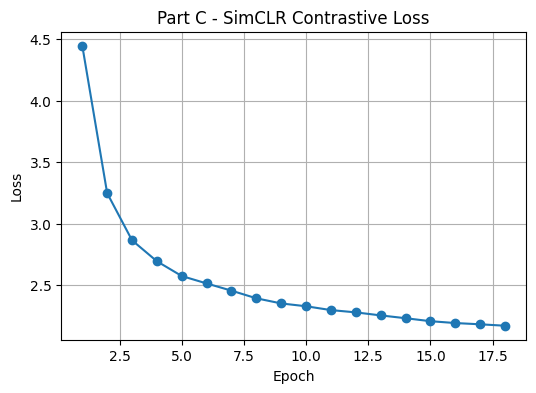

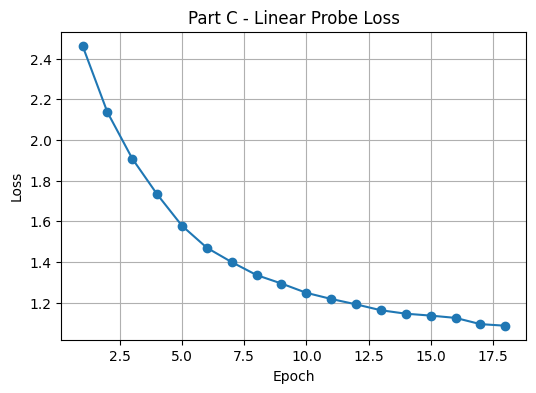

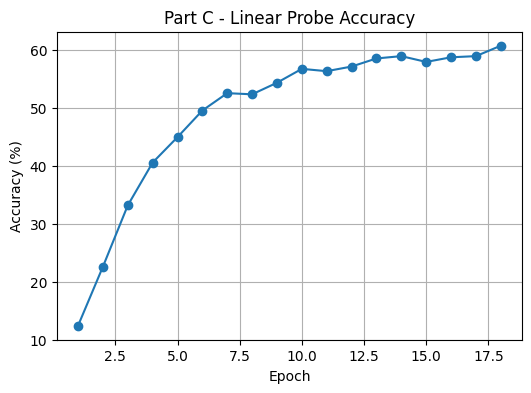

In [15]:
epochs_pre = range(1, len(hist_simclr_pretrain["loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_pre, hist_simclr_pretrain["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part C - SimCLR Contrastive Loss")
plt.grid(True)
plt.show()

epochs_probe = range(1, len(hist_simclr_probe["loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_probe, hist_simclr_probe["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part C - Linear Probe Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_probe, hist_simclr_probe["acc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Part C - Linear Probe Accuracy")
plt.grid(True)
plt.show()


Part D — Nearest Neighbor Visualization

In [16]:
supervised_encoder = supervised
supervised_encoder.fc = nn.Identity()

def get_embeddings(encoder, loader):
    encoder.eval()
    feats, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            z = encoder(x.to(device))
            feats.append(F.normalize(z, dim=1).cpu())
            labels.append(y)

    return torch.cat(feats), torch.cat(labels)

sup_emb, test_labels = get_embeddings(supervised_encoder, test_loader)
rot_emb, _ = get_embeddings(rotation_encoder, test_loader)
sim_emb, _ = get_embeddings(simclr_encoder, test_loader)

print(sup_emb.shape, rot_emb.shape, sim_emb.shape)

torch.Size([8000, 512]) torch.Size([8000, 512]) torch.Size([8000, 512])


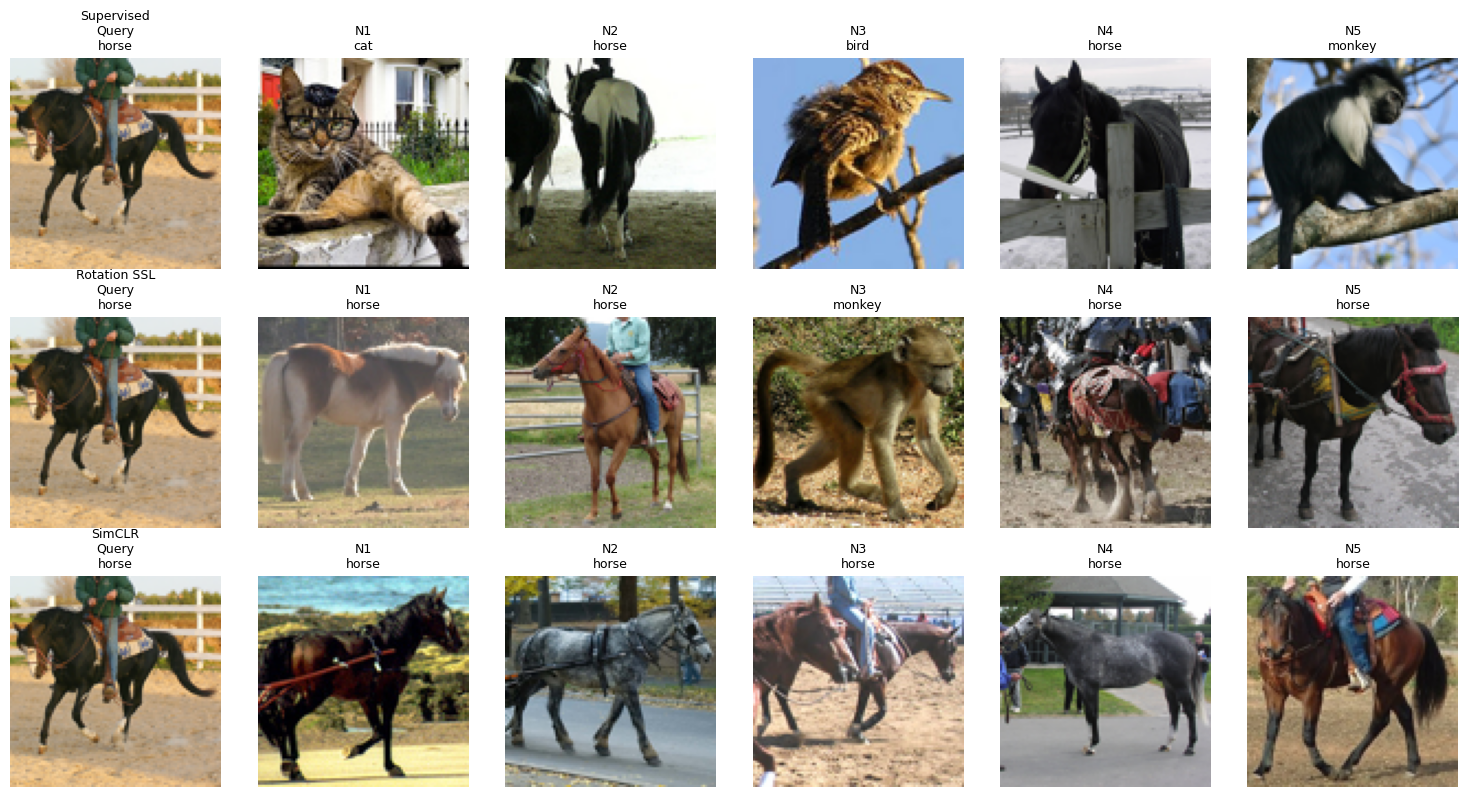

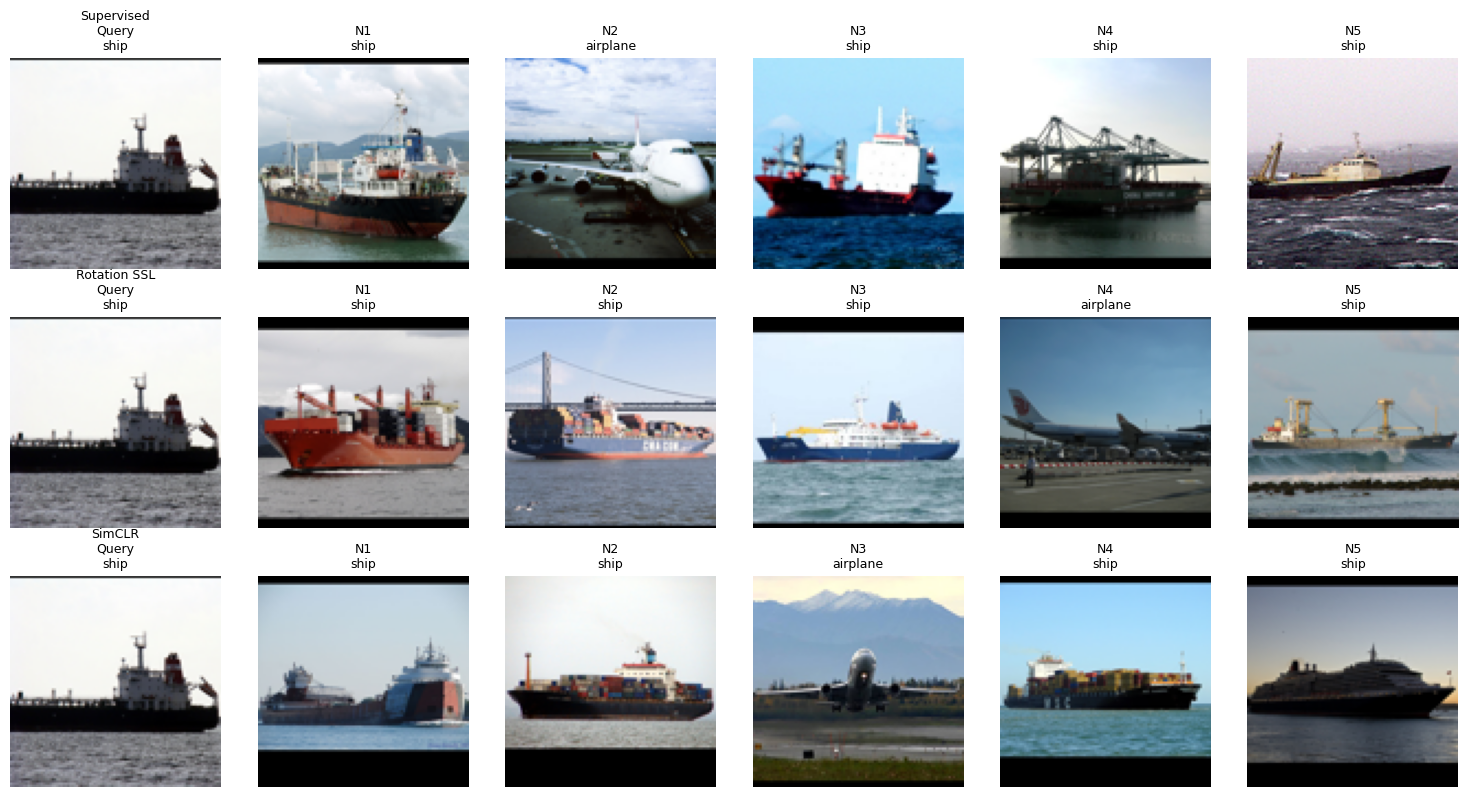

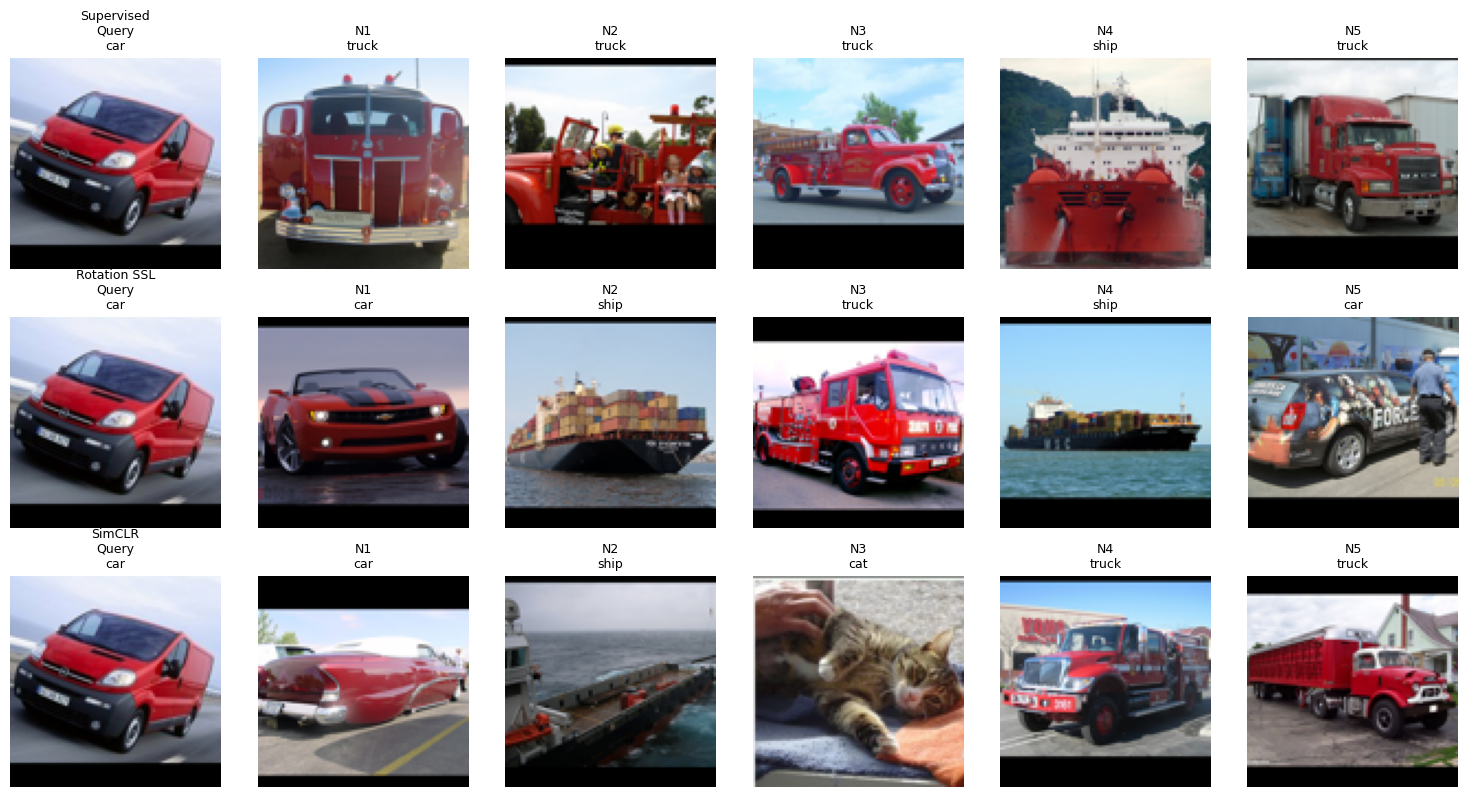

In [17]:
query_ids = [0, 100, 200]

def top5_neighbors(emb, q):
    scores = emb @ emb[q]
    scores[q] = -1
    return scores.topk(5).indices.tolist()

def show_neighbors(q):
    encoders = {
        "Supervised": sup_emb,
        "Rotation SSL": rot_emb,
        "SimCLR": sim_emb
    }

    fig, axes = plt.subplots(3, 6, figsize=(15, 8))
    raw_test = datasets.STL10(ROOT, split="test", download=False)

    for r, (name, emb) in enumerate(encoders.items()):
        ids = [q] + top5_neighbors(emb, q)

        for c, idx in enumerate(ids):
            img, label = raw_test[idx]
            axes[r, c].imshow(img)
            axes[r, c].axis("off")
            title = f"{name}\nQuery" if c == 0 else f"N{c}"
            axes[r, c].set_title(f"{title}\n{classes[label]}", fontsize=9)

    plt.tight_layout()
    plt.show()

for q in query_ids:
    show_neighbors(q)

Results

In [18]:
print(f"Supervised test accuracy : {acc_supervised:.2f}%")
print(f"Rotation SSL test accuracy: {acc_rotation:.2f}%")
print(f"SimCLR test accuracy      : {acc_simclr:.2f}%")

Supervised test accuracy : 34.20%
Rotation SSL test accuracy: 38.30%
SimCLR test accuracy      : 48.34%


Comparison

1. Among the three models, SimCLR performed best with 48.34% test accuracy. Rotation SSL reached 38.30%, while the supervised model reached 34.20%.
2. The supervised model reached 90.40% training accuracy but only 34.20% test accuracy. This large gap shows that the model overfit the small labeled training set and did not generalize well. It could be improved with more labeled data, stronger augmentation, regularization (weight decay, dropout), or early stopping.
3. Rotation SSL outperformed the supervised model by about 4.10 percentage points (38.30% vs. 34.20%). Predicting rotations let the encoder learn useful visual features from 100,000 unlabeled images before the linear classifier was trained. The gain was modest because rotation prediction can be solved with low-level cues (orientation of edges, sky position) without fully learning object identity. It could be improved with longer pretraining, adding augmentations during pretraining, or fine-tuning instead of only linear probing.
4. SimCLR gave the highest test accuracy because contrastive learning trains the encoder to map two augmented views of the same image to similar representations while pushing apart representations of different images. To succeed, the encoder must ignore nuisance changes (crop, flip, color, grayscale) and focus on the object itself, which produces features that transfer well to STL-10 classification even with a frozen encoder and only 500 labels. Its performance could be improved by using more unlabeled images, training for more epochs, using larger batch sizes (more negatives per step), and tuning the temperature and learning rate.
5. For the horse query, the supervised encoder returned 2/5 horses, Rotation SSL 4/5, and SimCLR 5/5. For the ship query, all three returned 4/5 ships, each with one airplane mistake, which is reasonable since both appear against sky or water. For the car query, all encoders struggled: supervised returned 0/5 cars (4 red trucks and a red ship), Rotation SSL 2/5, and SimCLR 1/5. The supervised neighbors suggest it relies heavily on color (red) rather than object shape, a sign of overfitting to superficial cues from only 500 labels. Overall, SimCLR produced the most class-consistent neighbors for horses and its mistakes were mostly visually related vehicles, but the improvement over the other methods is not uniform across queries.
